## Regression on Wine Quality


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

wine_df = pd.read_csv('data.csv')
wine_df = wine_df.dropna()
wine_df = wine_df.drop_duplicates()

X = wine_df.drop(['wine_type','quality'], axis=1)
y = wine_df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)


### Loading the best model

In [2]:
from assignment_1 import load_best_model

best_model_pipeline = load_best_model()

y_pred = best_model_pipeline.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {test_mse:.4f}")


Test MSE: 0.5009


### Visualising Results

   Degree  Train MSE  Validation MSE
0       1     0.5361          0.5716
1       2     0.4791          0.5476
2       3     0.4075          0.8394
3       4     0.2074        299.2788
4       5     0.0639     114296.3322
5       6     0.2031       6829.9272


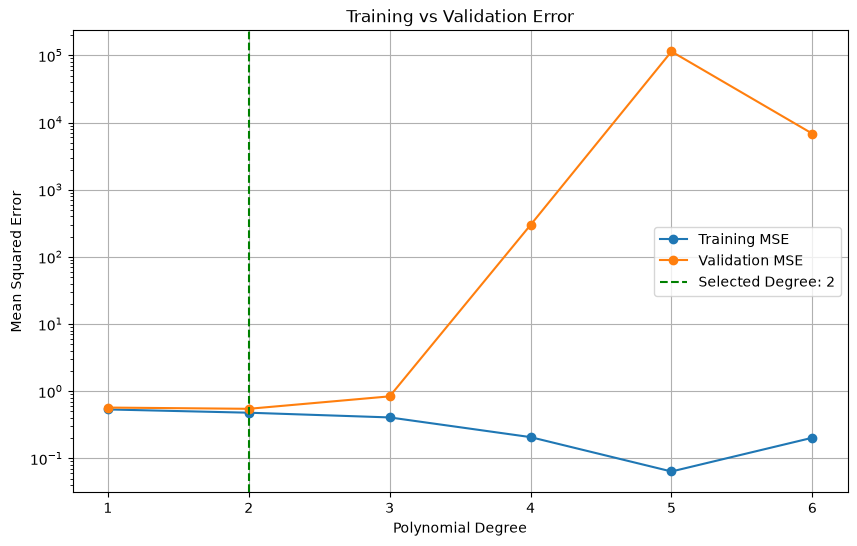

In [3]:
experiment_results = joblib.load('experiment_results.joblib')
degrees = experiment_results['degrees']
train_errors = experiment_results['train_errors']
val_errors = experiment_results['val_errors']
best_degree = experiment_results['best_degree']

result_df = pd.DataFrame({
    'Degree': degrees,
    'Train MSE': np.round(train_errors, 4),
    'Validation MSE': np.round(val_errors, 4)
})

print(result_df)

plt.figure(figsize=(10,6))
plt.plot(degrees, train_errors, marker = 'o', label = 'Training MSE')
plt.plot(degrees, val_errors, marker = 'o', label = 'Validation MSE')
plt.axvline(best_degree, color = 'green', linestyle = '--', label = f'Selected Degree: {best_degree}')
plt.yscale('log')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Validation Error')

plt.grid(True)
plt.legend()
plt.savefig('Figure1_Bias_Variance.png', dpi=200)
plt.show()

### Error Comparison

Test MSE: 0.5009
Test RMSE: 0.7078
Test MAE: 0.5510
Test R2: 0.3275
Baseline MSE: 0.7474


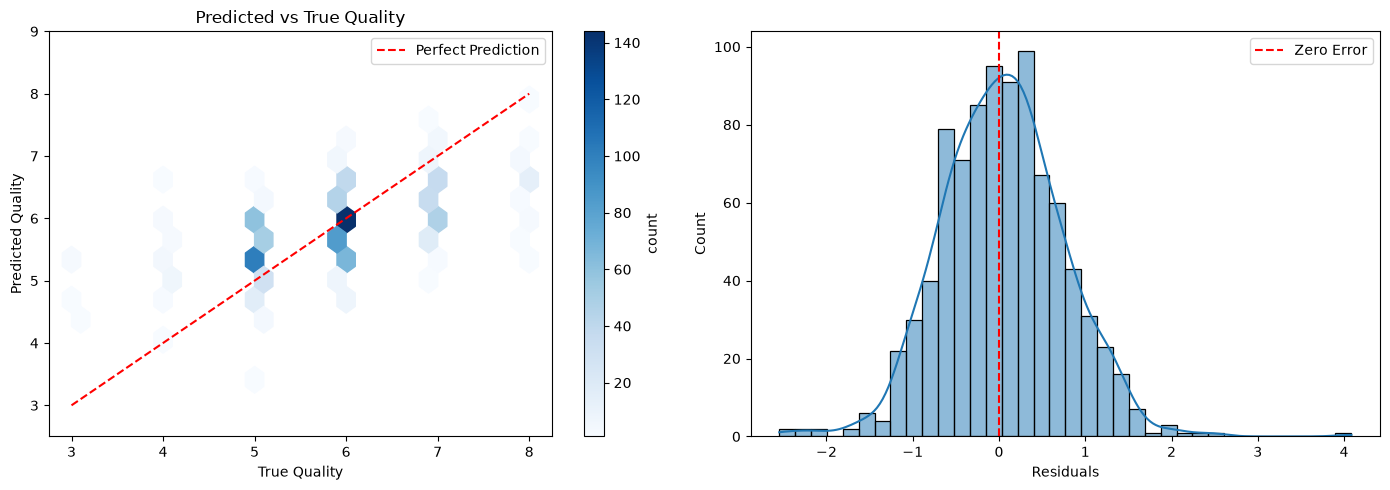

In [4]:
test_mse = mean_squared_error(y_test, y_pred)
print(f'Test MSE: {test_mse:.4f}')
print(f'Test RMSE: {np.sqrt(test_mse):.4f}')
print(f'Test MAE: {mean_absolute_error(y_test, y_pred):.4f}')
print(f'Test R2: {r2_score(y_test, y_pred):.4f}')

baseline_mse = mean_squared_error(y_test, np.full_like(y_test, y_train.mean(), dtype = float))
print(f'Baseline MSE: {baseline_mse:.4f}')

plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
plt.hexbin(y_test, y_pred, gridsize = 25, cmap = 'Blues', mincnt=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label = 'Perfect Prediction')
plt.colorbar(label='count')
plt.ylim(2.5, 9.0) #to make the graph look clean
plt.xlabel('True Quality')
plt.ylabel('Predicted Quality')
plt.title(f'Predicted vs True Quality')
plt.legend()

plt.subplot(1,2,2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.axvline(0, color = 'red', linestyle = '--', label = 'Zero Error')
plt.xlabel('Residuals')
plt.ylabel('Count')

plt.legend()
plt.tight_layout()
plt.savefig('Figure2_Test_Performance.png', dpi=200)
plt.show()

### Final Values

In [5]:
gaps = np.array(val_errors) - np.array(train_errors) #calculating error gaps
for d, g in zip(degrees, gaps):
    ratio = val_errors[d-1]/train_errors[d-1]
    print(f'Degree {d}: Gap = {g:>14,.4f}          Validation/Training ratio = {ratio:>12,.1f}x ')


print(f'\nValidation MSE improves {100*(val_errors[0]-val_errors[1])/val_errors[0]:.1f}% from degrees 1 to 2')
print(f'Reduction vs Baseline: {100*(1-test_mse/baseline_mse):.1f}%')
print(f'Validation vs test difference at degree {best_degree}: {abs(val_errors[best_degree-1] - test_mse):.4f}')

Degree 1: Gap =         0.0355          Validation/Training ratio =          1.1x 
Degree 2: Gap =         0.0685          Validation/Training ratio =          1.1x 
Degree 3: Gap =         0.4318          Validation/Training ratio =          2.1x 
Degree 4: Gap =       299.0713          Validation/Training ratio =      1,442.9x 
Degree 5: Gap =   114,296.2683          Validation/Training ratio =  1,790,022.0x 
Degree 6: Gap =     6,829.7241          Validation/Training ratio =     33,632.4x 

Validation MSE improves 4.2% from degrees 1 to 2
Reduction vs Baseline: 33.0%
Validation vs test difference at degree 2: 0.0467
